In [47]:
import numpy as np
import matplotlib.pyplot as plt
from unsflow.utils.plot_styles import *

In [48]:


# Stretching parameter
alpha = 2

# Computational coordinate
x = np.linspace(0, 1, 1000)

# Eriksson stretching functions
def f1(x, alpha):
    """Refinement towards x=0"""
    return (np.exp(alpha*x) - 1) / (np.exp(alpha) - 1)

def f2(x, alpha):
    """Refinement towards x=1"""
    return (np.exp(alpha) - np.exp(alpha*(1-x))) / (np.exp(alpha) - 1)

def f3(x, alpha):
    """Double refinement towards x=0 and x=1"""
    x1 = 0.5
    y = np.zeros_like(x)

    left = x <= x1
    right = x > x1

    y[left] = x1 * (np.exp(alpha*x[left]/x1) - 1) / (np.exp(alpha)-1)

    y[right] = 1 - (1-x1) * (
        (np.exp(alpha*(1-x[right])/(1-x1)) - 1)
        / (np.exp(alpha)-1)
    )

    return y

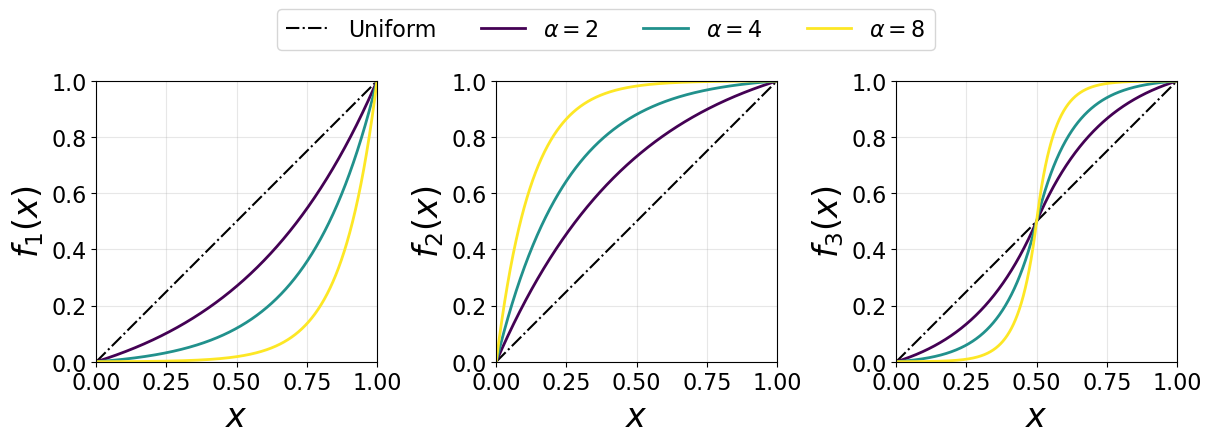

In [55]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

functions = [
    (f1(x, alpha), r"$f_1(x)$"),
    (f2(x, alpha), r"$f_2(x)$"),
    (f3(x, alpha), r"$f_3(x)$")
]

functions2 = [
    (f1(x, alpha*2), r"$f_1(x)$"),
    (f2(x, alpha*2), r"$f_2(x)$"),
    (f3(x, alpha*2), r"$f_3(x)$")
]

functions3 = [
    (f1(x, alpha*4), r"$f_1(x)$"),
    (f2(x, alpha*4), r"$f_2(x)$"),
    (f3(x, alpha*4), r"$f_3(x)$")
]

cmap = plt.colormaps["viridis"]

for i, (y, title) in enumerate(functions):
    ax[i].plot(x, x, "-.k", linewidth=1.5, label="Uniform")
    ax[i].plot(x, y, '-',linewidth=2, label=r"$\alpha=%i$" % alpha, color=cmap(0.0))
    ax[i].plot(x, functions2[i][0], '-',linewidth=2, label=r"$\alpha=%i$" % (alpha*2), color=cmap(0.5))
    ax[i].plot(x, functions3[i][0], '-',linewidth=2, label=r"$\alpha=%i$" % (alpha*4), color=cmap(1.0))

    ax[i].set_xlabel(r"$x$")
    ax[i].set_ylabel(title)

    ax[i].set_xlim(0, 1)
    ax[i].set_ylim(0, 1)
    ax[i].set_aspect("equal")

    ax[i].grid(alpha=0.3)
    if i == 0:
        fig.legend(bbox_to_anchor=(0.5, 1.02), loc="center", ncol=4)

plt.savefig("erikkson_stretching_functions.pdf", bbox_inches="tight")